# Importing Libraries

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Loading Dataset

In [58]:
df = pd.read_csv(r"C:\Users\gs602\Downloads\heart.csv")

In [59]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# EDA , DATA CLEANING & DATA VISUALIZATION

In [60]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [61]:
df.shape

(918, 12)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


<Axes: xlabel='HeartDisease'>

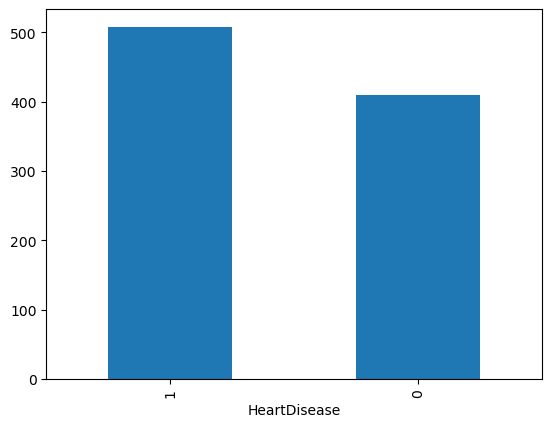

In [65]:
df['HeartDisease'].value_counts().plot(kind = 'bar')

In [66]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

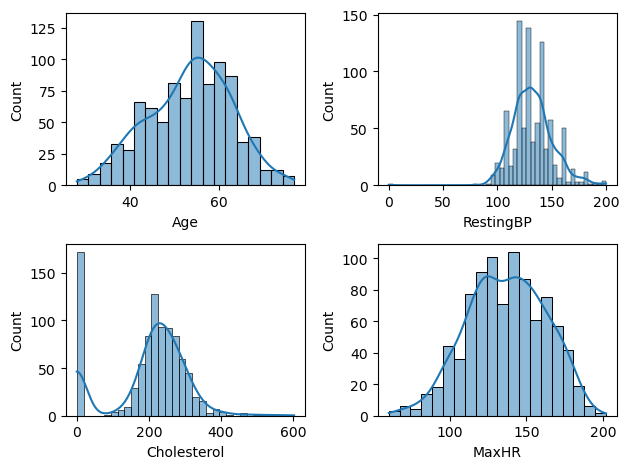

In [67]:
def plotting(var , num):
    plt.subplot(2 , 2 , num)
    sns.histplot(df[var] , kde = True)

plotting('Age', 1)
plotting('RestingBP' , 2)
plotting('Cholesterol' , 3)
plotting('MaxHR' , 4)


plt.tight_layout()

In [68]:
ch_mean = df.loc[df['Cholesterol'] != 0 , 'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [69]:
df['Cholesterol'] = df['Cholesterol'].replace(0 , ch_mean)
df['Cholestrol'] = df['Cholesterol'].round(2)

In [70]:
rbp_mean = df.loc[df['RestingBP'] != 0 , 'RestingBP'].mean()
rbp_mean

np.float64(132.54089422028352)

In [71]:
df['RestingBP'] = df['RestingBP'].replace(0 , rbp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

In [72]:
op_mean = df.loc[df['Oldpeak'] != 0 ,'Oldpeak'].mean()
op_mean

np.float64(1.4810909090909092)

In [73]:
df['Oldpeak'] = df['Oldpeak'].replace(0 , op_mean)
df['Oldpeak'] = df['Oldpeak'].round(2)

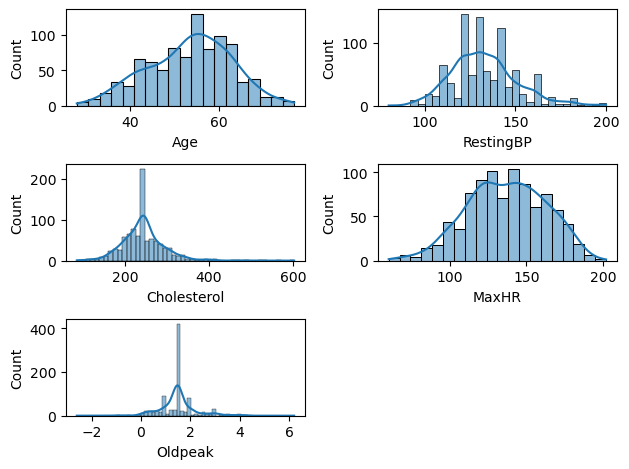

In [74]:
def plotting(var , num):
    plt.subplot(3 , 2 , num)
    sns.histplot(df[var] , kde = True)

plotting('Age', 1)
plotting('RestingBP' , 2)
plotting('Cholesterol' , 3)
plotting('MaxHR' , 4)
plotting('Oldpeak' , 5)

plt.tight_layout()

In [75]:
pip install sheryanalysis==0.1.0

Note: you may need to restart the kernel to use updated packages.


In [76]:
import sheryanalysis as sh
sh.analyze(df)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 13)
🧱 Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease', 'Cholestrol']

✅ No null values found

🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Cholestrol']


{'shape': (918, 13),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease',
  'Cholestrol'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': dtype('O'),
  'ChestPainType': dtype('O'),
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': dtype('O'),
  'MaxHR': dtype('int64'),
  'ExerciseAngina': dtype('O'),
  'Oldpeak': dtype('float64'),
  'ST_Slope': dtype('O'),
  'HeartDisease': dtype('int64'),
  'Cholestrol': dtype('float64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0,
  'Cholestrol': 0},
 'total_rows': 918,
 'column_types': {'categorical': ['Sex',
   'ChestPainType',
   'FastingBS',
   'RestingECG',
   'ExerciseAng

<Axes: xlabel='Sex', ylabel='count'>

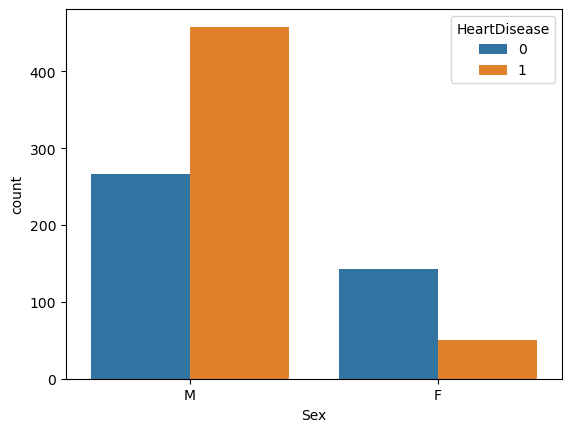

In [77]:
sns.countplot(x = 'Sex' , hue = 'HeartDisease' , data=df)

<Axes: xlabel='ChestPainType', ylabel='count'>

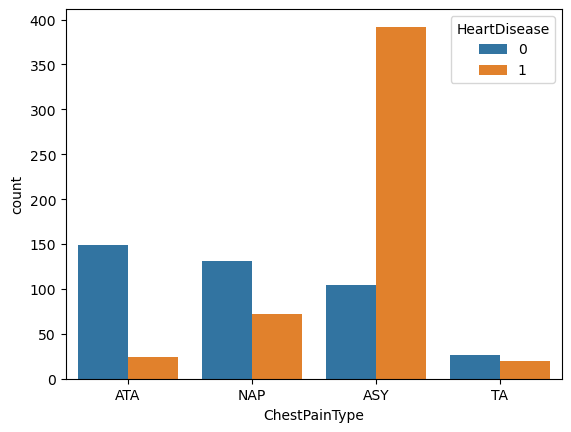

In [78]:
sns.countplot(x = 'ChestPainType' , hue = 'HeartDisease' , data=df)

<Axes: xlabel='FastingBS', ylabel='count'>

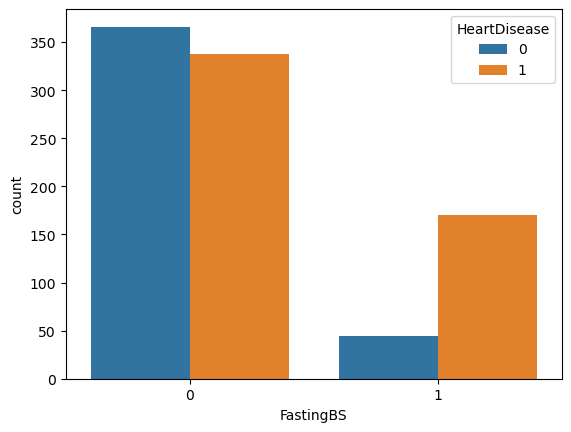

In [79]:
sns.countplot(data = df , x = 'FastingBS' , hue = 'HeartDisease')

<Axes: xlabel='RestingECG', ylabel='count'>

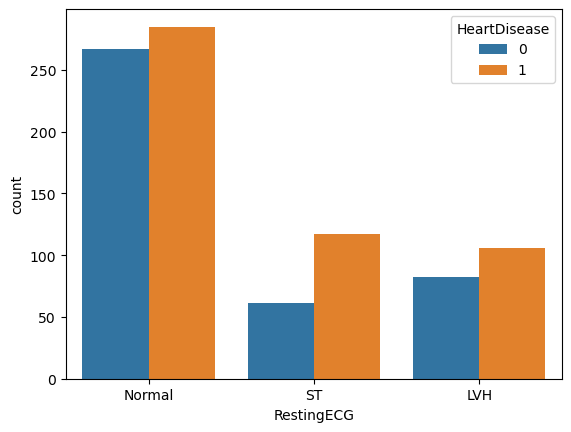

In [80]:
sns.countplot(data = df , x = 'RestingECG' , hue = 'HeartDisease')

<Axes: >

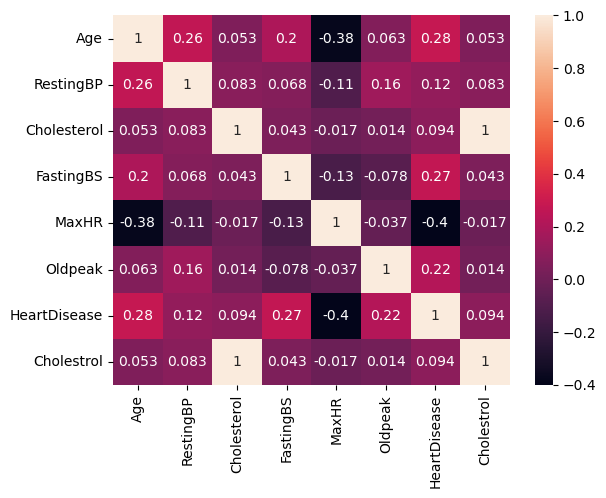

In [81]:
sns.heatmap(df.corr(numeric_only = True) , annot = True)

# DATA PREPROCESSING

In [82]:
df_encode = pd.get_dummies(df , drop_first = True)

In [83]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Cholestrol,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,1.48,0,289.0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.00,1,180.0,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,1.48,0,283.0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.50,1,214.0,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,1.48,0,195.0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.20,1,264.0,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.40,1,193.0,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.20,1,131.0,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,1.48,1,236.0,False,True,False,False,False,False,False,True,False


In [85]:
df_encode = df_encode.astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Cholestrol,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,1,0,289,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,180,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,1,0,283,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,214,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,1,0,195,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,264,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,193,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,131,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,1,1,236,0,1,0,0,0,0,0,1,0


In [87]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = ['Age' , 'RestingBP' , 'Cholesterol' , 'MaxHR' , 'Oldpeak']
df_encode[numeric_cols] = scaler.fit_transform(df_encode[numeric_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Cholestrol,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.15088,0,289,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,-0.15088,1,180,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.15088,0,283,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,-0.15088,1,214,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.15088,0,195,1,0,1,0,1,0,0,0,1
